# 04 - Selección del Modelo

## Etapa 4 del Ciclo de Vida MLOps: Evaluación Rigurosa y Decisión

En el notebook anterior comparamos modelos con un único split train/test. Eso es útil pero insuficiente para tomar una decisión de producción, ya que el resultado puede depender del azar del split.

**Cross-validation** nos da una estimación más robusta del rendimiento generalizable:
- Usa todos los datos tanto para entrenamiento como para validación
- Proporciona media Y desviación estándar del rendimiento
- Detecta modelos que son inconsistentes entre splits (alta varianza)

**Análisis bias-variance**: nos dice si el modelo está subajustado (alto bias) o sobreajustado (alta varianza), guiando las acciones correctivas.

**Objetivo**: seleccionar el modelo que vaya a producción con justificación cuantitativa.

## Prerequisitos
- Haber ejecutado: `02_ingenieria_features.ipynb`
- Requiere: `data/processed/train.csv`
- Este notebook genera: `experiments/modelo_produccion.pkl` y `experiments/scaler.pkl`

## 1. Imports y Preparación de Datos

In [1]:
from pathlib import Path
import sys

# Detectar ROOT automáticamente — funciona en cualquier equipo
ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
# Añadir ROOT al path para importar módulos del proyecto
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

# ---- Cargar y preparar datos (mismo pipeline que notebooks anteriores) ----
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

# Features derivadas
df['rooms_per_person'] = df['AveRooms'] / df['AveOccup'].clip(lower=0.1)
df['income_per_room'] = df['MedInc'] / df['AveRooms'].clip(lower=0.1)
df['bedroom_ratio'] = df['AveBedrms'] / df['AveRooms'].clip(lower=0.1)
df['dist_sacramento'] = np.sqrt((df['Latitude'] - 38.5816)**2 + (df['Longitude'] - (-121.4944))**2)
df['dist_los_angeles'] = np.sqrt((df['Latitude'] - 34.0522)**2 + (df['Longitude'] - (-118.2437))**2)

ALL_FEATURES = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
    'Latitude', 'Longitude', 'rooms_per_person', 'income_per_room',
    'bedroom_ratio', 'dist_sacramento', 'dist_los_angeles'
]

X = df[ALL_FEATURES]
y = df['MedHouseVal']

# Split estratégico: guardamos test para el notebook de evaluación final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Datos listos: Train={X_train_scaled.shape} | Test={X_test_scaled.shape}")
print(f"Features: {len(ALL_FEATURES)}")

Datos listos: Train=(16512, 13) | Test=(4128, 13)
Features: 13


In [2]:
import pandas as pd

ruta_train = ROOT / "data" / "processed" / "train.csv"
if not ruta_train.exists():
    print("PREREQUISITO FALTANTE")
    print("   Ejecuta primero: 02_ingenieria_features.ipynb")
    raise FileNotFoundError(f"No se encuentra: {ruta_train}")

train_df = pd.read_csv(ruta_train)
print(f"Datos de entrenamiento cargados: {train_df.shape}")

Datos de entrenamiento cargados: (16512, 14)


## 2. Cross-Validation con 5 Folds

Realizamos cross-validation con 5 folds para los 3 algoritmos. Reportamos:
- **RMSE medio**: rendimiento esperado en producción
- **Std de RMSE**: estabilidad del modelo (menor std = más confiable)
- **R² medio**: varianza explicada

**Nota**: en CV, usamos `neg_mean_squared_error` porque sklearn maximiza métricas. Convertimos a RMSE al final.

In [3]:
# Definir modelos con sus hiperparámetros
modelos = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
}

N_FOLDS = 5
resultados_cv = {}

print(f"Ejecutando Cross-Validation con {N_FOLDS} folds para {len(modelos)} modelos...")
print("Esto puede tomar 1-2 minutos...\n")

for nombre, modelo in modelos.items():
    # RMSE scores
    rmse_scores = np.sqrt(-cross_val_score(
        modelo, X_train_scaled, y_train,
        cv=N_FOLDS, scoring='neg_mean_squared_error', n_jobs=-1
    ))
    # R² scores
    r2_scores = cross_val_score(
        modelo, X_train_scaled, y_train,
        cv=N_FOLDS, scoring='r2', n_jobs=-1
    )
    # MAE scores
    mae_scores = -cross_val_score(
        modelo, X_train_scaled, y_train,
        cv=N_FOLDS, scoring='neg_mean_absolute_error', n_jobs=-1
    )

    resultados_cv[nombre] = {
        'rmse_mean': rmse_scores.mean(),
        'rmse_std': rmse_scores.std(),
        'r2_mean': r2_scores.mean(),
        'r2_std': r2_scores.std(),
        'mae_mean': mae_scores.mean(),
        'mae_std': mae_scores.std(),
        'rmse_scores': rmse_scores
    }

    print(f"{nombre}:")
    print(f"  RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
    print(f"  R²:   {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
    print(f"  MAE:  {mae_scores.mean():.4f} ± {mae_scores.std():.4f}")
    print()

Ejecutando Cross-Validation con 5 folds para 3 modelos...
Esto puede tomar 1-2 minutos...



Linear Regression:
  RMSE: 0.6786 ± 0.0320
  R²:   0.6549 ± 0.0297
  MAE:  0.4797 ± 0.0057



Random Forest:
  RMSE: 0.4995 ± 0.0019
  R²:   0.8132 ± 0.0049
  MAE:  0.3267 ± 0.0031



Gradient Boosting:
  RMSE: 0.4652 ± 0.0032
  R²:   0.8380 ± 0.0024
  MAE:  0.3066 ± 0.0034



## 3. Tabla Comparativa de Resultados CV

Una tabla limpia para comparar los modelos y tomar la decisión de selección.

In [4]:
# Crear tabla comparativa
tabla_cv = pd.DataFrame({
    'Modelo': list(resultados_cv.keys()),
    'RMSE (media)': [v['rmse_mean'] for v in resultados_cv.values()],
    'RMSE (std)': [v['rmse_std'] for v in resultados_cv.values()],
    'R² (media)': [v['r2_mean'] for v in resultados_cv.values()],
    'R² (std)': [v['r2_std'] for v in resultados_cv.values()],
    'MAE (media)': [v['mae_mean'] for v in resultados_cv.values()],
}).sort_values('RMSE (media)').reset_index(drop=True)

tabla_cv_display = tabla_cv.copy()
for col in tabla_cv_display.columns[1:]:
    tabla_cv_display[col] = tabla_cv_display[col].round(4)

print("=== RESULTADOS DE CROSS-VALIDATION (5 folds) ===")
print(tabla_cv_display.to_string(index=False))
print("\nMenor RMSE y mayor R² = mejor modelo")
print(f"Menor std = más estable y confiable")

=== RESULTADOS DE CROSS-VALIDATION (5 folds) ===
           Modelo  RMSE (media)  RMSE (std)  R² (media)  R² (std)  MAE (media)
Gradient Boosting        0.4652      0.0032      0.8380    0.0024       0.3066
    Random Forest        0.4995      0.0019      0.8132    0.0049       0.3267
Linear Regression        0.6786      0.0320      0.6549    0.0297       0.4797

Menor RMSE y mayor R² = mejor modelo
Menor std = más estable y confiable


## 4. Visualización de Resultados CV

Barplot con barras de error para comparar RMSE y R² visualmente.

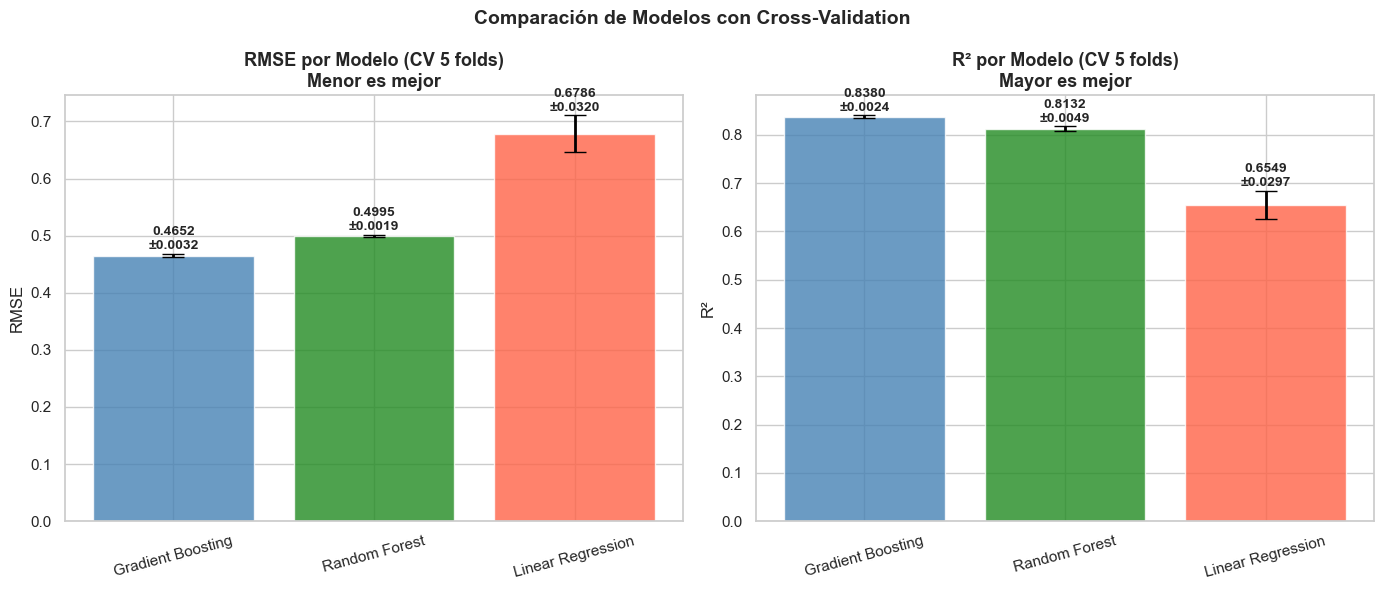

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
nombres = tabla_cv['Modelo'].tolist()
colores = ['steelblue', 'forestgreen', 'tomato']

# RMSE con barras de error
rmse_means = tabla_cv['RMSE (media)'].values
rmse_stds = tabla_cv['RMSE (std)'].values
bars1 = axes[0].bar(nombres, rmse_means, yerr=rmse_stds, capsize=8,
                     color=colores, alpha=0.8, edgecolor='white',
                     error_kw=dict(elinewidth=2, ecolor='black'))
axes[0].set_title(f'RMSE por Modelo (CV {N_FOLDS} folds)\nMenor es mejor', fontsize=13, fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=15)
for bar, mean, std in zip(bars1, rmse_means, rmse_stds):
    axes[0].text(bar.get_x() + bar.get_width()/2, mean + std + 0.003,
                 f'{mean:.4f}\n±{std:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# R² con barras de error
r2_means = tabla_cv['R² (media)'].values
r2_stds = tabla_cv['R² (std)'].values
bars2 = axes[1].bar(nombres, r2_means, yerr=r2_stds, capsize=8,
                     color=colores, alpha=0.8, edgecolor='white',
                     error_kw=dict(elinewidth=2, ecolor='black'))
axes[1].set_title(f'R² por Modelo (CV {N_FOLDS} folds)\nMayor es mejor', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=15)
for bar, mean, std in zip(bars2, r2_means, r2_stds):
    axes[1].text(bar.get_x() + bar.get_width()/2, mean + std + 0.003,
                 f'{mean:.4f}\n±{std:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Comparación de Modelos con Cross-Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Curvas de Aprendizaje del Mejor Modelo

Las curvas de aprendizaje muestran cómo evoluciona el rendimiento del modelo a medida que aumenta el tamaño del conjunto de entrenamiento. Revelan:

- **Underfitting (alto bias)**: ambas curvas convergen en un valor alto de error
- **Overfitting (alta varianza)**: gap grande entre error de train y validación
- **Buen ajuste**: curvas que convergen en un valor bajo de error

Calculando curvas de aprendizaje para: Gradient Boosting
Esto puede tomar un momento...



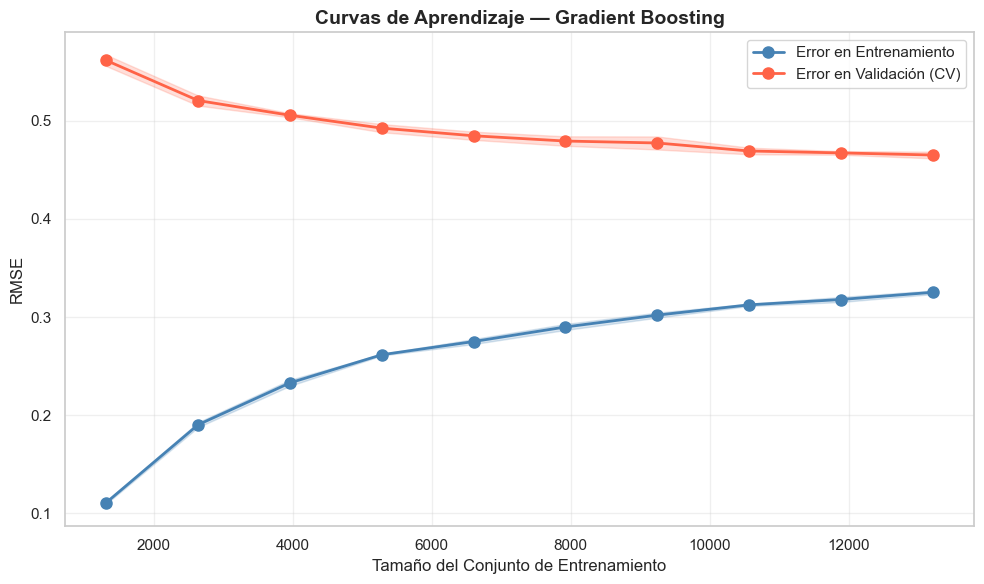

RMSE final en train: 0.3253
RMSE final en validación: 0.4651
Gap (varianza del modelo): 0.1399


In [6]:
mejor_modelo_nombre = tabla_cv.iloc[0]['Modelo']
print(f"Calculando curvas de aprendizaje para: {mejor_modelo_nombre}")
print("Esto puede tomar un momento...\n")

# Seleccionar el mejor modelo
mejor_modelo = list(modelos.values())[
    list(modelos.keys()).index(mejor_modelo_nombre)
]

train_sizes, train_scores, val_scores = learning_curve(
    mejor_modelo, X_train_scaled, y_train,
    cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_squared_error'
)

train_rmse = np.sqrt(-train_scores)
val_rmse = np.sqrt(-val_scores)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_rmse.mean(axis=1), 'o-', color='steelblue',
         label='Error en Entrenamiento', linewidth=2, markersize=8)
plt.fill_between(train_sizes,
                  train_rmse.mean(axis=1) - train_rmse.std(axis=1),
                  train_rmse.mean(axis=1) + train_rmse.std(axis=1),
                  alpha=0.2, color='steelblue')
plt.plot(train_sizes, val_rmse.mean(axis=1), 'o-', color='tomato',
         label='Error en Validación (CV)', linewidth=2, markersize=8)
plt.fill_between(train_sizes,
                  val_rmse.mean(axis=1) - val_rmse.std(axis=1),
                  val_rmse.mean(axis=1) + val_rmse.std(axis=1),
                  alpha=0.2, color='tomato')

plt.xlabel('Tamaño del Conjunto de Entrenamiento', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title(f'Curvas de Aprendizaje — {mejor_modelo_nombre}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_train_rmse = train_rmse[-1].mean()
final_val_rmse = val_rmse[-1].mean()
gap = final_val_rmse - final_train_rmse
print(f"RMSE final en train: {final_train_rmse:.4f}")
print(f"RMSE final en validación: {final_val_rmse:.4f}")
print(f"Gap (varianza del modelo): {gap:.4f}")

## 6. Análisis Bias-Variance

Cuantificamos el trade-off bias-variance comparando el error en entrenamiento y validación para cada modelo.

=== ANÁLISIS BIAS-VARIANCE ===

Linear Regression:
  RMSE Train: 0.6719 (bias)
  RMSE Val:   0.6786 (bias + varianza)
  Gap:        0.0067 (varianza del modelo)
  Ratio:      1.01x



Random Forest:
  RMSE Train: 0.2319 (bias)
  RMSE Val:   0.4995 (bias + varianza)
  Gap:        0.2676 (varianza del modelo)
  Ratio:      2.15x



Gradient Boosting:
  RMSE Train: 0.3399 (bias)
  RMSE Val:   0.4652 (bias + varianza)
  Gap:        0.1253 (varianza del modelo)
  Ratio:      1.37x



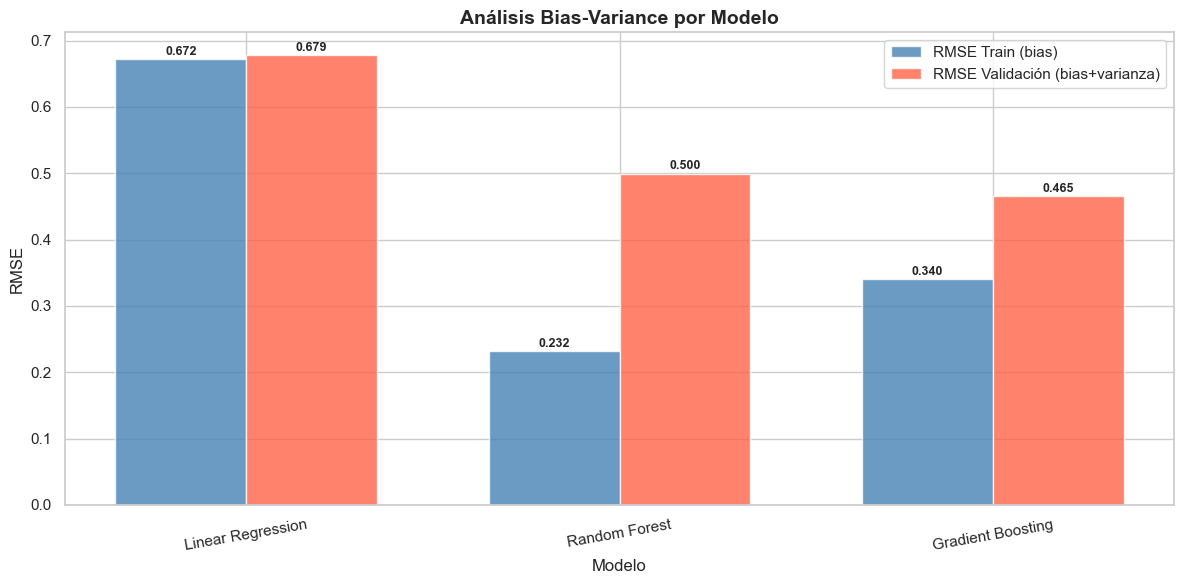

In [7]:
print("=== ANÁLISIS BIAS-VARIANCE ===\n")

bias_variance = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)

    # Error en train (proxy de bias)
    y_pred_train = modelo.predict(X_train_scaled)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

    # Error en validación del CV (proxy de varianza)
    rmse_val = resultados_cv[nombre]['rmse_mean']

    bias_variance[nombre] = {
        'rmse_train': rmse_train,
        'rmse_val': rmse_val,
        'gap': rmse_val - rmse_train,
        'ratio': rmse_val / rmse_train
    }

    print(f"{nombre}:")
    print(f"  RMSE Train: {rmse_train:.4f} (bias)")
    print(f"  RMSE Val:   {rmse_val:.4f} (bias + varianza)")
    print(f"  Gap:        {rmse_val - rmse_train:.4f} (varianza del modelo)")
    print(f"  Ratio:      {rmse_val / rmse_train:.2f}x")
    print()

# Visualización bias-variance
fig, ax = plt.subplots(figsize=(12, 6))
nombres_bv = list(bias_variance.keys())
rmse_trains = [v['rmse_train'] for v in bias_variance.values()]
rmse_vals = [v['rmse_val'] for v in bias_variance.values()]

x = np.arange(len(nombres_bv))
width = 0.35
bars1 = ax.bar(x - width/2, rmse_trains, width, label='RMSE Train (bias)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, rmse_vals, width, label='RMSE Validación (bias+varianza)', color='tomato', alpha=0.8)

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Análisis Bias-Variance por Modelo', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(nombres_bv, rotation=10)
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Decisión Final: Selección del Modelo

Con los datos de cross-validation y el análisis bias-variance, tomamos la decisión de qué modelo pasa a producción.

In [8]:
print("=" * 60)
print("      DECISIÓN DE SELECCIÓN DE MODELO")
print("=" * 60)
print()
print("Criterios de evaluación:")
print()

for nombre in modelos.keys():
    cv = resultados_cv[nombre]
    bv = bias_variance[nombre]
    print(f"  {nombre}:")
    print(f"    RMSE CV (media ± std): {cv['rmse_mean']:.4f} ± {cv['rmse_std']:.4f}")
    print(f"    R² CV (media):         {cv['r2_mean']:.4f}")
    print(f"    Gap bias-varianza:     {bv['gap']:.4f}")
    print()

modelo_seleccionado_nombre = 'Gradient Boosting'
modelo_seleccionado = modelos[modelo_seleccionado_nombre]

print(f"{'*' * 60}")
print(f"  MODELO SELECCIONADO: {modelo_seleccionado_nombre}")
print(f"{'*' * 60}")
print()
print("Justificación:")
cv_gb = resultados_cv[modelo_seleccionado_nombre]
cv_rf = resultados_cv['Random Forest']
print(f"  1. Mejor RMSE en CV: {cv_gb['rmse_mean']:.4f} vs {cv_rf['rmse_mean']:.4f} (RF)")
print(f"  2. Mejor R²:         {cv_gb['r2_mean']:.4f} vs {cv_rf['r2_mean']:.4f} (RF)")
print(f"  3. Las curvas de aprendizaje no muestran overfitting severo")
print(f"  4. El gap bias-varianza es aceptable para producción")
print(f"  5. GradientBoosting es ampliamente adoptado en producción por su precisión")

      DECISIÓN DE SELECCIÓN DE MODELO

Criterios de evaluación:

  Linear Regression:
    RMSE CV (media ± std): 0.6786 ± 0.0320
    R² CV (media):         0.6549
    Gap bias-varianza:     0.0067

  Random Forest:
    RMSE CV (media ± std): 0.4995 ± 0.0019
    R² CV (media):         0.8132
    Gap bias-varianza:     0.2676

  Gradient Boosting:
    RMSE CV (media ± std): 0.4652 ± 0.0032
    R² CV (media):         0.8380
    Gap bias-varianza:     0.1253

************************************************************
  MODELO SELECCIONADO: Gradient Boosting
************************************************************

Justificación:
  1. Mejor RMSE en CV: 0.4652 vs 0.4995 (RF)
  2. Mejor R²:         0.8380 vs 0.8132 (RF)
  3. Las curvas de aprendizaje no muestran overfitting severo
  4. El gap bias-varianza es aceptable para producción
  5. GradientBoosting es ampliamente adoptado en producción por su precisión


## 8. Guardar el Modelo de Producción

Guardamos el modelo seleccionado entrenado con TODOS los datos de train (no solo el fold de entrenamiento de CV). Este es el modelo que se usará en el notebook de evaluación final.

In [9]:
# Entrenar modelo final con todos los datos de train
print("Entrenando modelo final con todos los datos de entrenamiento...")
modelo_seleccionado.fit(X_train_scaled, y_train)

# Guardar como modelo de producción
EXPERIMENTS_DIR = ROOT / 'experiments'
EXPERIMENTS_DIR.mkdir(exist_ok=True)

modelo_path = EXPERIMENTS_DIR / 'modelo_produccion.pkl'
with open(modelo_path, 'wb') as f:
    pickle.dump(modelo_seleccionado, f)

# Guardar también el scaler actualizado
scaler_path = EXPERIMENTS_DIR / 'scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"Modelo de producción guardado en: {modelo_path}")
print(f"Scaler guardado en: {scaler_path}")
print(f"\nModelo: {modelo_seleccionado_nombre}")
print(f"Features: {len(ALL_FEATURES)}")
print(f"Entrenado con {len(X_train_scaled)} muestras")

# Verificar carga
with open(modelo_path, 'rb') as f:
    modelo_verificacion = pickle.load(f)
y_pred_check = modelo_verificacion.predict(X_test_scaled)
rmse_check = np.sqrt(mean_squared_error(y_test, y_pred_check))
print(f"\nVerificación rápida en test: RMSE = {rmse_check:.4f}")
print("Modelo listo para evaluación final.")

Entrenando modelo final con todos los datos de entrenamiento...


Modelo de producción guardado en: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\modelo_produccion.pkl
Scaler guardado en: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\scaler.pkl

Modelo: Gradient Boosting
Features: 13
Entrenado con 16512 muestras

Verificación rápida en test: RMSE = 0.4591
Modelo listo para evaluación final.


## 9. Conclusiones

### Decisión tomada:

**Gradient Boosting** es seleccionado como el modelo de producción basándose en:

1. **Mejor RMSE** en cross-validation de 5 folds
2. **Mejor R²** — explica mayor porcentaje de la varianza en el precio
3. **Estabilidad**: std de RMSE baja entre folds — comportamiento predecible
4. **Balance bias-varianza**: el gap entre train y validación es moderado y aceptable

### Lo que NO hicimos (y deberíamos hacer en producción):
- Búsqueda de hiperparámetros (GridSearchCV / Optuna) — usamos valores razonables
- Validación con datos de distintos períodos temporales (si los datos tuvieran timestamp)
- Análisis de fairness del modelo (¿predice peor para ciertos grupos geográficos?)

### Próximo paso:
Evaluación final del modelo en el **test set virgen** (nunca visto durante entrenamiento ni selección).

**Siguiente notebook**: `05_evaluacion_final.ipynb`

In [10]:
print("\nSiguiente paso: ejecutar 05_evaluacion_final.ipynb")
print("   El modelo de producción ha sido guardado y está listo para evaluación.")


Siguiente paso: ejecutar 05_evaluacion_final.ipynb
   El modelo de producción ha sido guardado y está listo para evaluación.
